# Chapter 11: Gradient Descent Deep Dive

This notebook provides a comprehensive exploration of gradient descent:

1. Gradient Descent from Scratch
2. Learning Rate Effects (too small, good, too large)
3. Momentum Visualization
4. Convergence Plotting

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact

# Configure matplotlib
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
np.random.seed(42)

## 1. Gradient Descent from Scratch

Gradient descent is the fundamental optimization algorithm in machine learning:

$$x_{t+1} = x_t - \eta \nabla f(x_t)$$

Where:
- $x_t$ is the current parameter value
- $\eta$ is the learning rate (step size)
- $\nabla f(x_t)$ is the gradient at $x_t$

In [2]:
def gradient_descent(grad_fn, x_init, lr=0.01, n_steps=100, callback=None):
    """
    Vanilla gradient descent optimizer.
    
    Parameters:
        grad_fn: Function that computes gradient at a point
        x_init: Initial parameter values
        lr: Learning rate
        n_steps: Number of optimization steps
        callback: Optional function called each step with (step, x, grad)
    
    Returns:
        path: List of parameter values at each step
    """
    x = np.array(x_init, dtype=float)
    path = [x.copy()]
    
    for step in range(n_steps):
        grad = grad_fn(x)
        x = x - lr * grad
        path.append(x.copy())
        
        if callback:
            callback(step, x, grad)
    
    return path

# Example usage on a simple quadratic
def f_quad(x):
    """f(x, y) = x^2 + 2y^2"""
    return x[0]**2 + 2*x[1]**2

def grad_quad(x):
    """Gradient: [2x, 4y]"""
    return np.array([2*x[0], 4*x[1]])

# Run gradient descent
x_init = np.array([4.0, 3.0])
path = gradient_descent(grad_quad, x_init, lr=0.1, n_steps=50)

print(f"Starting point: {x_init}")
print(f"Final point: {path[-1]}")
print(f"Starting loss: {f_quad(x_init):.6f}")
print(f"Final loss: {f_quad(path[-1]):.10f}")

Starting point: [4. 3.]
Final point: [5.70899077e-05 2.42484383e-11]
Starting loss: 34.000000
Final loss: 0.0000000033


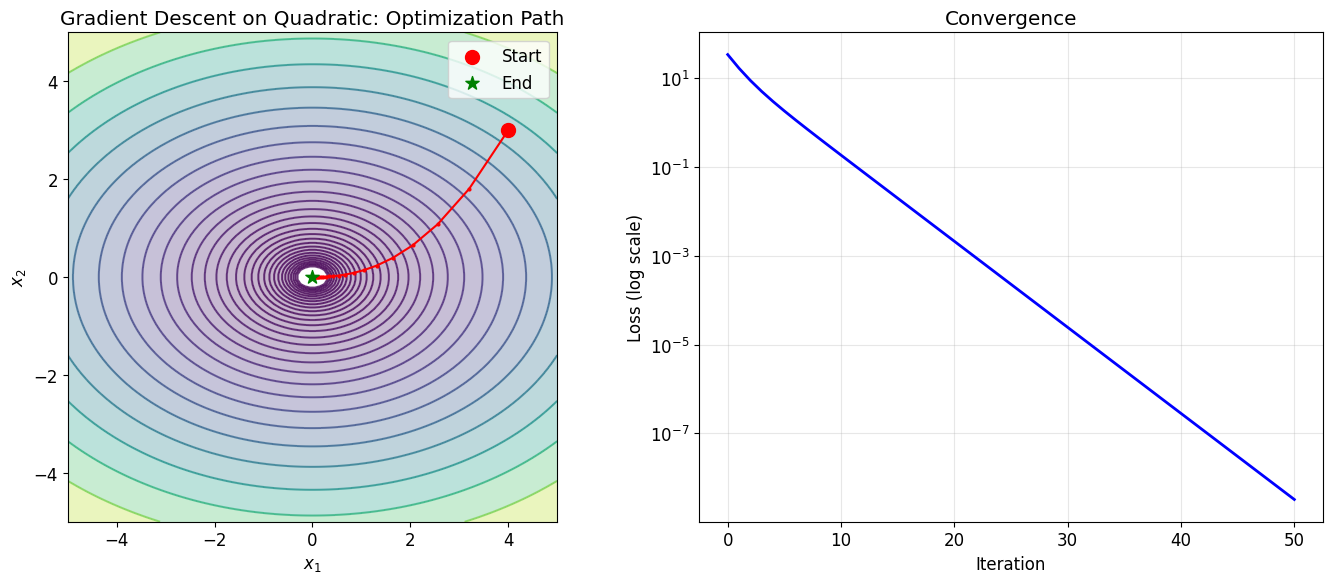

In [3]:
# Visualize gradient descent on the quadratic
def plot_optimization(f, path, title="Gradient Descent", xlim=(-5, 5), ylim=(-5, 5)):
    """
    Plot contours and optimization path.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Create contour plot
    x_range = np.linspace(xlim[0], xlim[1], 100)
    y_range = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
    
    # Left: Contour with path
    ax = axes[0]
    levels = np.logspace(-1, np.log10(Z.max()), 30)
    ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.3)
    
    path_array = np.array(path)
    ax.plot(path_array[:, 0], path_array[:, 1], 'r.-', markersize=4, linewidth=1.5)
    ax.scatter(path_array[0, 0], path_array[0, 1], color='red', s=100, zorder=5, label='Start')
    ax.scatter(path_array[-1, 0], path_array[-1, 1], color='green', s=100, marker='*', zorder=5, label='End')
    
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{title}: Optimization Path')
    ax.legend()
    ax.set_aspect('equal')
    
    # Right: Loss curve
    ax = axes[1]
    losses = [f(p) for p in path]
    ax.semilogy(losses, 'b-', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title('Convergence')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_optimization(f_quad, path, "Gradient Descent on Quadratic")

## 2. Learning Rate Effects

The learning rate $\eta$ is crucial:
- **Too small**: Slow convergence
- **Just right**: Fast, stable convergence
- **Too large**: Oscillation or divergence

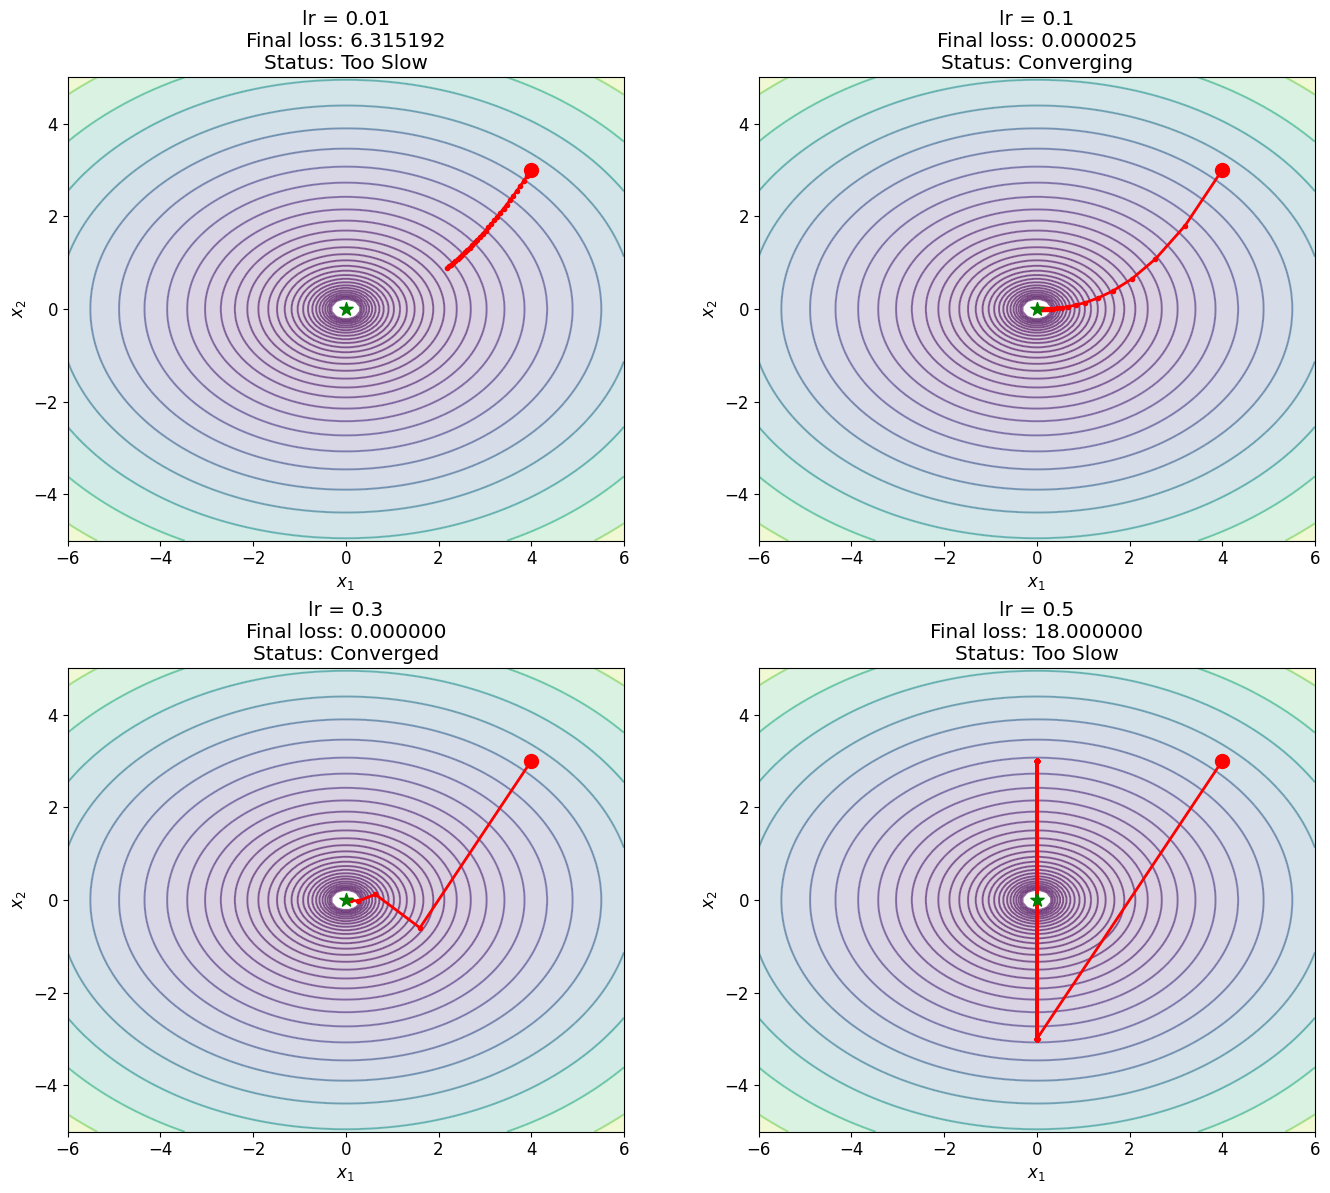

In [4]:
# Compare different learning rates
learning_rates = [0.01, 0.1, 0.3, 0.5]
x_init = np.array([4.0, 3.0])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Create contour data
x_range = np.linspace(-6, 6, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + 2*Y**2

for ax, lr in zip(axes, learning_rates):
    path = gradient_descent(grad_quad, x_init, lr=lr, n_steps=30)
    path_array = np.array(path)
    
    # Contours
    levels = np.logspace(-1, 2, 30)
    ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.2)
    
    # Path
    ax.plot(path_array[:, 0], path_array[:, 1], 'r.-', markersize=6, linewidth=2)
    ax.scatter(path_array[0, 0], path_array[0, 1], color='red', s=100, zorder=5)
    ax.scatter(0, 0, color='green', s=100, marker='*', zorder=5)
    
    # Determine behavior
    final_loss = f_quad(path_array[-1])
    if final_loss > f_quad(x_init):
        status = "Diverging"
    elif final_loss > 0.1:
        status = "Too Slow"
    elif final_loss < 1e-6:
        status = "Converged"
    else:
        status = "Converging"
    
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'lr = {lr}\nFinal loss: {final_loss:.6f}\nStatus: {status}')
    ax.set_xlim(-6, 6)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

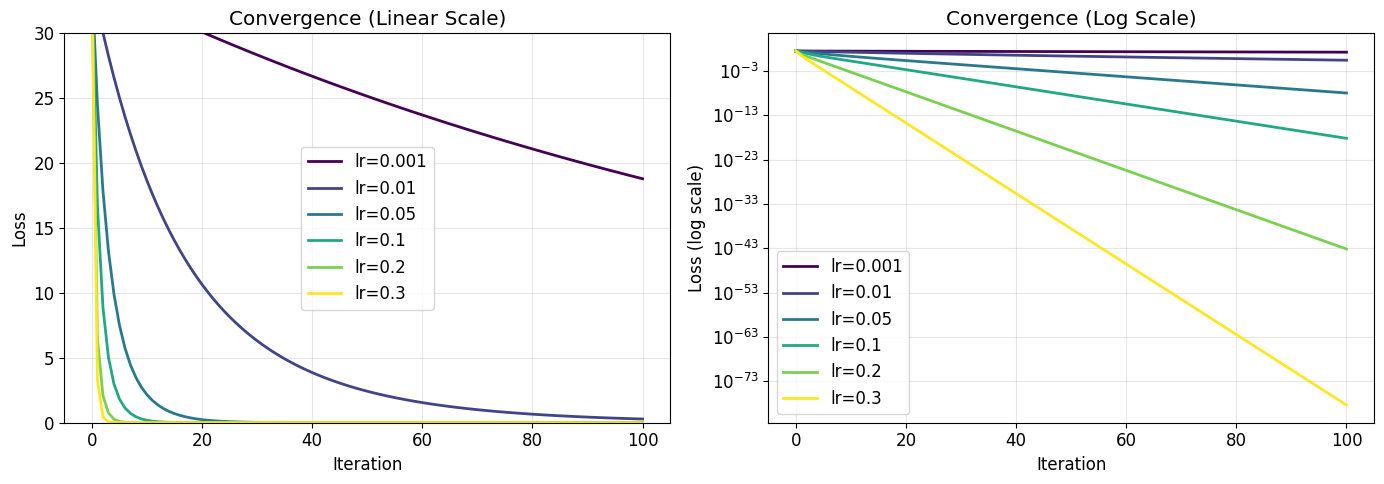

In [5]:
# Convergence curves for different learning rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_init = np.array([4.0, 3.0])
n_steps = 100

learning_rates_detailed = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates_detailed)))

# Linear scale
ax = axes[0]
for lr, color in zip(learning_rates_detailed, colors):
    path = gradient_descent(grad_quad, x_init, lr=lr, n_steps=n_steps)
    losses = [f_quad(p) for p in path]
    ax.plot(losses, color=color, linewidth=2, label=f'lr={lr}')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Convergence (Linear Scale)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 30)

# Log scale
ax = axes[1]
for lr, color in zip(learning_rates_detailed, colors):
    path = gradient_descent(grad_quad, x_init, lr=lr, n_steps=n_steps)
    losses = [f_quad(p) for p in path]
    ax.semilogy(losses, color=color, linewidth=2, label=f'lr={lr}')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Convergence (Log Scale)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

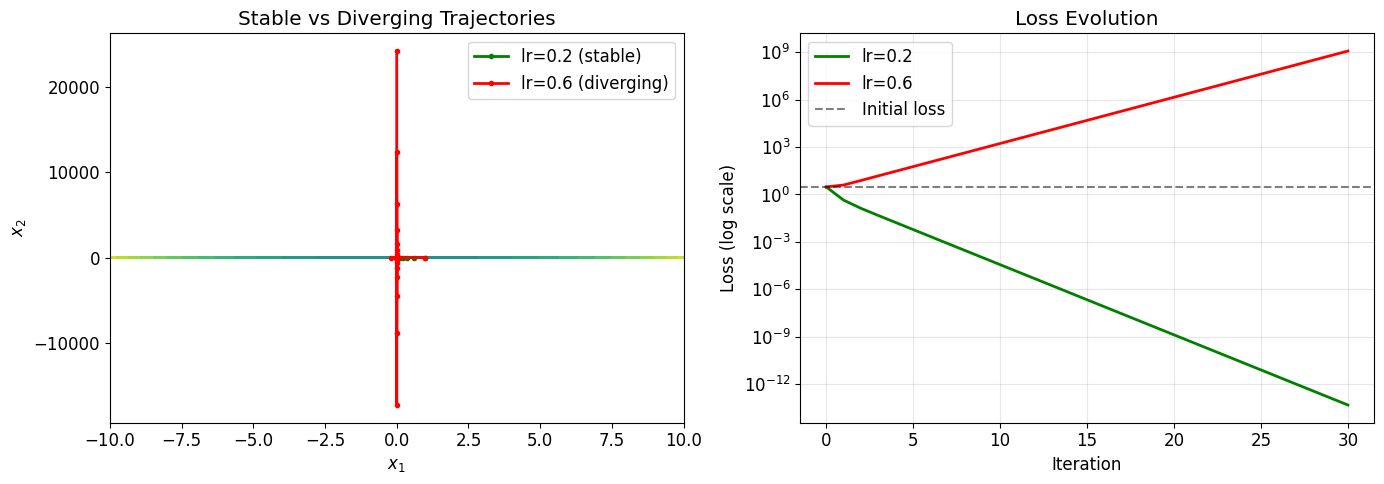

With lr=0.2: Final loss = 0.000000
With lr=0.6: Final loss = 1.17e+09


In [6]:
# Demonstrate divergence with too-large learning rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_init = np.array([1.0, 1.0])
lr_stable = 0.2
lr_diverge = 0.6

# Stable
path_stable = gradient_descent(grad_quad, x_init, lr=lr_stable, n_steps=30)
losses_stable = [f_quad(p) for p in path_stable]

# Diverging
path_diverge = gradient_descent(grad_quad, x_init, lr=lr_diverge, n_steps=30)
losses_diverge = [f_quad(p) for p in path_diverge]

# Contours
ax = axes[0]
x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-8, 8, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + 2*Y**2

ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.5)

path_s = np.array(path_stable)
path_d = np.array(path_diverge)

ax.plot(path_s[:, 0], path_s[:, 1], 'g.-', markersize=6, linewidth=2, label=f'lr={lr_stable} (stable)')
ax.plot(path_d[:, 0], path_d[:, 1], 'r.-', markersize=6, linewidth=2, label=f'lr={lr_diverge} (diverging)')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Stable vs Diverging Trajectories')
ax.legend()

# Loss curves
ax = axes[1]
ax.semilogy(losses_stable, 'g-', linewidth=2, label=f'lr={lr_stable}')
ax.semilogy(losses_diverge, 'r-', linewidth=2, label=f'lr={lr_diverge}')
ax.axhline(y=f_quad(x_init), color='k', linestyle='--', alpha=0.5, label='Initial loss')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Loss Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"With lr={lr_stable}: Final loss = {losses_stable[-1]:.6f}")
print(f"With lr={lr_diverge}: Final loss = {losses_diverge[-1]:.2e}")

## 3. Momentum Visualization

Momentum helps accelerate gradient descent by accumulating past gradients:

$$v_{t+1} = \beta v_t + \nabla f(x_t)$$
$$x_{t+1} = x_t - \eta v_{t+1}$$

This helps:
- Accelerate convergence in consistent gradient directions
- Dampen oscillations in high-curvature directions

In [7]:
def gradient_descent_momentum(grad_fn, x_init, lr=0.01, beta=0.9, n_steps=100):
    """
    Gradient descent with momentum.
    
    Parameters:
        grad_fn: Function that computes gradient at a point
        x_init: Initial parameter values
        lr: Learning rate
        beta: Momentum coefficient (typically 0.9)
        n_steps: Number of optimization steps
    
    Returns:
        path: List of parameter values at each step
    """
    x = np.array(x_init, dtype=float)
    v = np.zeros_like(x)  # Velocity
    path = [x.copy()]
    
    for _ in range(n_steps):
        grad = grad_fn(x)
        v = beta * v + grad
        x = x - lr * v
        path.append(x.copy())
    
    return path

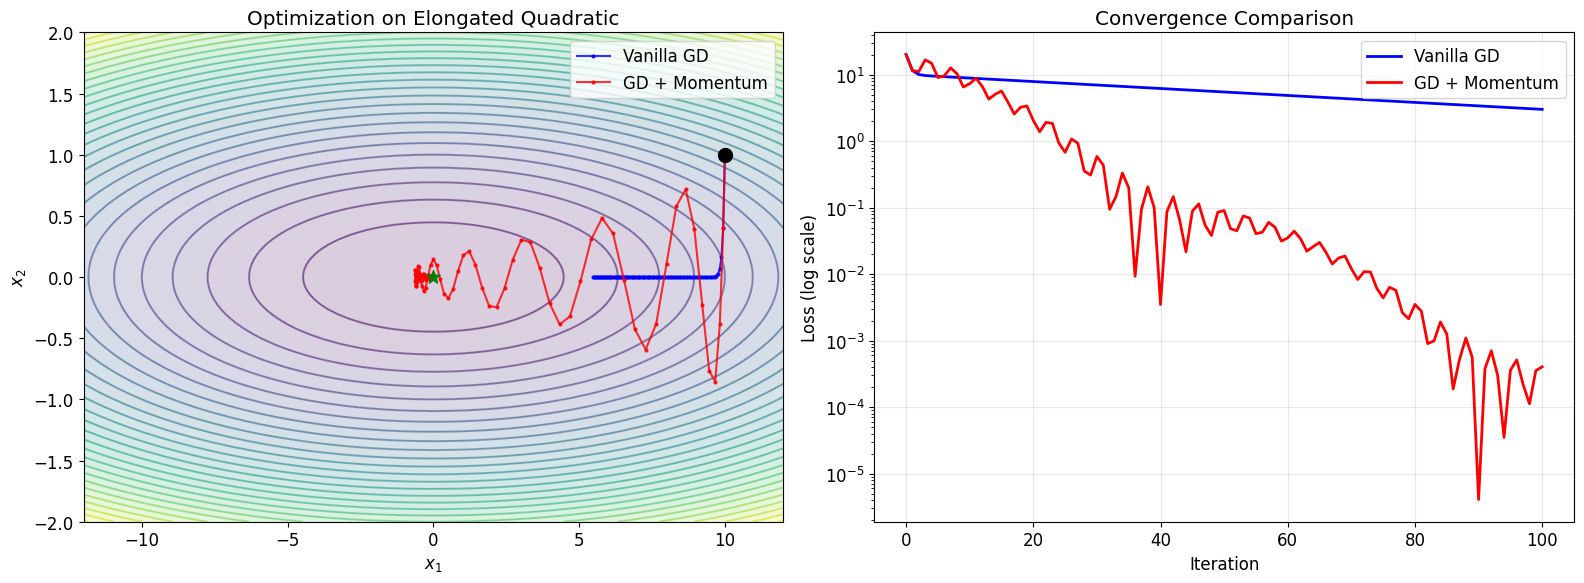

Vanilla GD: Final loss = 3.001075
Momentum:   Final loss = 0.000404


In [8]:
# Compare GD with and without momentum on an elongated quadratic
def f_elongated(x):
    """f(x, y) = 0.1*x^2 + 10*y^2 (highly elongated)"""
    return 0.1*x[0]**2 + 10*x[1]**2

def grad_elongated(x):
    return np.array([0.2*x[0], 20*x[1]])

x_init = np.array([10.0, 1.0])
lr = 0.03
n_steps = 100

# Vanilla GD
path_vanilla = gradient_descent(grad_elongated, x_init, lr=lr, n_steps=n_steps)

# GD with momentum
path_momentum = gradient_descent_momentum(grad_elongated, x_init, lr=lr, beta=0.9, n_steps=n_steps)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour plot
ax = axes[0]
x_range = np.linspace(-12, 12, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = 0.1*X**2 + 10*Y**2

ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.5)
ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.2)

path_v = np.array(path_vanilla)
path_m = np.array(path_momentum)

ax.plot(path_v[:, 0], path_v[:, 1], 'b.-', markersize=4, linewidth=1.5, 
        label='Vanilla GD', alpha=0.8)
ax.plot(path_m[:, 0], path_m[:, 1], 'r.-', markersize=4, linewidth=1.5, 
        label='GD + Momentum', alpha=0.8)

ax.scatter(x_init[0], x_init[1], color='black', s=100, zorder=5, marker='o')
ax.scatter(0, 0, color='green', s=100, marker='*', zorder=5)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Optimization on Elongated Quadratic')
ax.legend()

# Loss curves
ax = axes[1]
losses_v = [f_elongated(p) for p in path_vanilla]
losses_m = [f_elongated(p) for p in path_momentum]

ax.semilogy(losses_v, 'b-', linewidth=2, label='Vanilla GD')
ax.semilogy(losses_m, 'r-', linewidth=2, label='GD + Momentum')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Convergence Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Vanilla GD: Final loss = {losses_v[-1]:.6f}")
print(f"Momentum:   Final loss = {losses_m[-1]:.6f}")

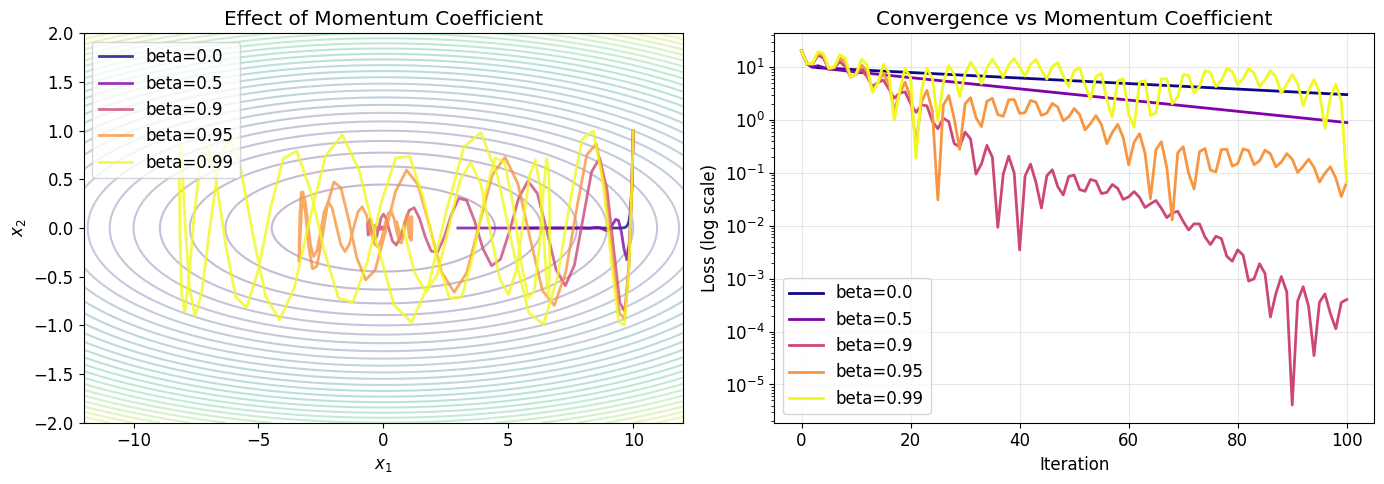

In [9]:
# Effect of momentum coefficient beta
betas = [0.0, 0.5, 0.9, 0.95, 0.99]
colors = plt.cm.plasma(np.linspace(0, 1, len(betas)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.3)

for beta, color in zip(betas, colors):
    path = gradient_descent_momentum(grad_elongated, x_init, lr=0.03, beta=beta, n_steps=100)
    path_arr = np.array(path)
    ax.plot(path_arr[:, 0], path_arr[:, 1], color=color, linewidth=2, 
            label=f'beta={beta}', alpha=0.8)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Effect of Momentum Coefficient')
ax.legend()

ax = axes[1]
for beta, color in zip(betas, colors):
    path = gradient_descent_momentum(grad_elongated, x_init, lr=0.03, beta=beta, n_steps=100)
    losses = [f_elongated(p) for p in path]
    ax.semilogy(losses, color=color, linewidth=2, label=f'beta={beta}')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Convergence vs Momentum Coefficient')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Convergence Analysis

Let's analyze convergence on different loss landscapes.

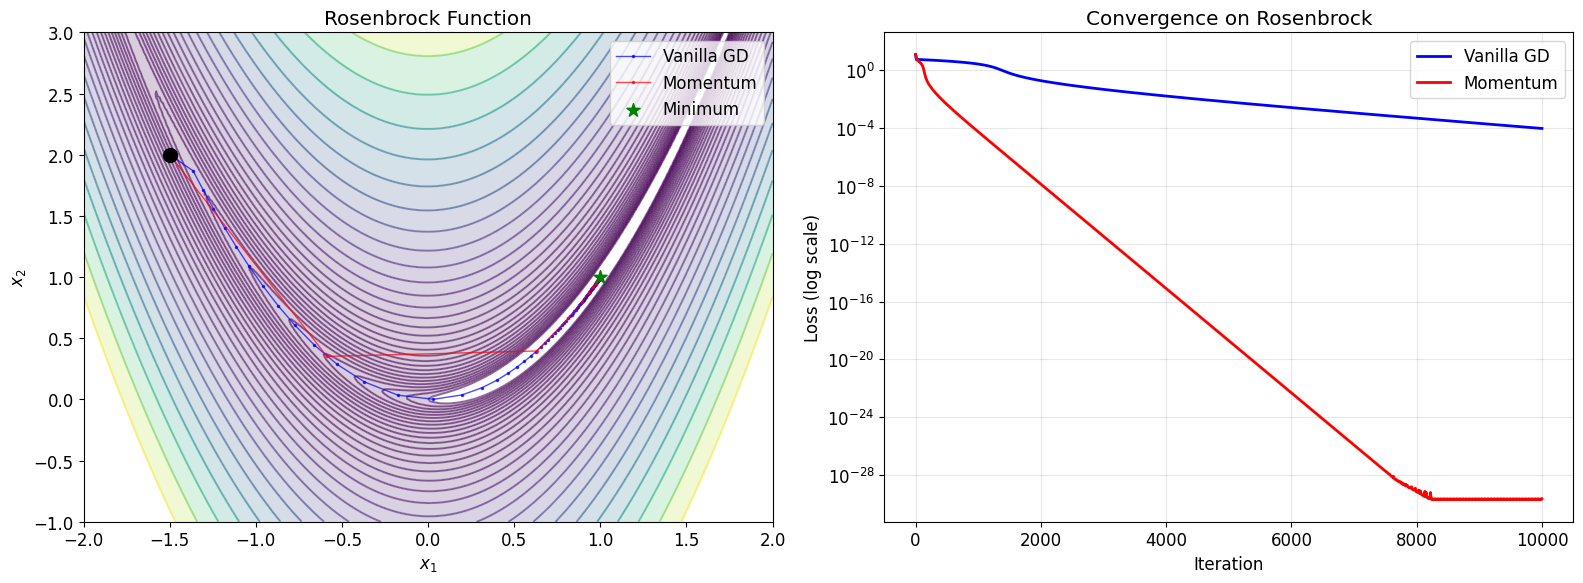

Vanilla GD final point: [0.99020202 0.98046061]
Momentum final point: [1. 1.]
True minimum: (1, 1)


In [10]:
# Test on Rosenbrock function (a challenging optimization landscape)
def rosenbrock(x):
    """Rosenbrock function: minimum at (1, 1)"""
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dfdx0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dfdx1 = 200*(x[1] - x[0]**2)
    return np.array([dfdx0, dfdx1])

# Run optimization
x_init = np.array([-1.5, 2.0])
n_steps = 10000

path_vanilla = gradient_descent(grad_rosenbrock, x_init, lr=0.001, n_steps=n_steps)
path_momentum = gradient_descent_momentum(grad_rosenbrock, x_init, lr=0.001, beta=0.9, n_steps=n_steps)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour
ax = axes[0]
x_range = np.linspace(-2, 2, 200)
y_range = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100*(Y - X**2)**2

levels = np.logspace(0, 3, 30)
ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.2)

# Sample paths for visualization (full path too dense)
sample_rate = 100
path_v_sample = np.array(path_vanilla[::sample_rate])
path_m_sample = np.array(path_momentum[::sample_rate])

ax.plot(path_v_sample[:, 0], path_v_sample[:, 1], 'b.-', markersize=3, 
        linewidth=1, label='Vanilla GD', alpha=0.7)
ax.plot(path_m_sample[:, 0], path_m_sample[:, 1], 'r.-', markersize=3, 
        linewidth=1, label='Momentum', alpha=0.7)

ax.scatter(x_init[0], x_init[1], color='black', s=100, marker='o', zorder=5)
ax.scatter(1, 1, color='green', s=100, marker='*', zorder=5, label='Minimum')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Rosenbrock Function')
ax.legend()

# Convergence
ax = axes[1]
losses_v = [rosenbrock(p) for p in path_vanilla[::10]]
losses_m = [rosenbrock(p) for p in path_momentum[::10]]

ax.semilogy(np.arange(len(losses_v))*10, losses_v, 'b-', linewidth=2, label='Vanilla GD')
ax.semilogy(np.arange(len(losses_m))*10, losses_m, 'r-', linewidth=2, label='Momentum')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Convergence on Rosenbrock')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Vanilla GD final point: {path_vanilla[-1]}")
print(f"Momentum final point: {path_momentum[-1]}")
print(f"True minimum: (1, 1)")

In [11]:
# Interactive gradient descent explorer
def interactive_gd(function='Quadratic', lr=0.05, momentum=0.0, n_steps=50):
    """
    Interactive gradient descent visualization.
    """
    # Select function
    if function == 'Quadratic':
        f = f_quad
        grad_f = grad_quad
        x_init = np.array([4.0, 3.0])
        xlim, ylim = (-5, 5), (-4, 4)
    elif function == 'Elongated':
        f = f_elongated
        grad_f = grad_elongated
        x_init = np.array([10.0, 1.0])
        xlim, ylim = (-12, 12), (-2, 2)
    else:  # Rosenbrock
        f = rosenbrock
        grad_f = grad_rosenbrock
        x_init = np.array([-1.5, 2.0])
        xlim, ylim = (-2, 2), (-1, 3)
    
    # Run optimization
    path = gradient_descent_momentum(grad_f, x_init, lr=lr, beta=momentum, n_steps=n_steps)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Contour
    ax = axes[0]
    x_range = np.linspace(xlim[0], xlim[1], 100)
    y_range = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
    
    levels = 30
    ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.2)
    
    path_arr = np.array(path)
    ax.plot(path_arr[:, 0], path_arr[:, 1], 'r.-', markersize=4, linewidth=1.5)
    ax.scatter(path_arr[0, 0], path_arr[0, 1], color='red', s=100, zorder=5)
    
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{function} Function')
    
    # Loss
    ax = axes[1]
    losses = [f(p) for p in path]
    ax.semilogy(losses, 'b-', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title('Convergence')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final loss: {losses[-1]:.6f}")
    print(f"Final position: {path[-1]}")

interact(interactive_gd,
         function=['Quadratic', 'Elongated', 'Rosenbrock'],
         lr=widgets.FloatSlider(min=0.001, max=0.5, step=0.01, value=0.05, description='Learning Rate'),
         momentum=widgets.FloatSlider(min=0, max=0.99, step=0.05, value=0, description='Momentum'),
         n_steps=widgets.IntSlider(min=10, max=500, step=10, value=50, description='Steps'));

interactive(children=(Dropdown(description='function', options=('Quadratic', 'Elongated', 'Rosenbrock'), value…

## Summary

In this notebook, we explored gradient descent in depth:

1. **Vanilla Gradient Descent**: Simple but effective, $x \leftarrow x - \eta \nabla f$
2. **Learning Rate Effects**:
   - Too small: slow convergence
   - Too large: oscillation or divergence
   - Just right: fast, stable convergence
3. **Momentum**: Accelerates convergence by accumulating past gradients
4. **Convergence Behavior**: Depends on loss landscape geometry

### Key Takeaways:

- Learning rate is the most important hyperparameter
- Momentum helps with ill-conditioned problems (elongated loss landscapes)
- The loss landscape geometry determines optimization difficulty
- Visualizing optimization paths builds intuition

---

*Continue to Chapter 12 for advanced optimizers (Adam, RMSprop)...*